Section 1: Load Dataset & Konversi Tipe Data
Tahapan ini memuat file CSV, menampilkan data "mentah" sebelum diapa-apakan, kemudian membersihkan kurung siku [ ] dari atribut tempo agar dikenali sebagai nilai numerik (float).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score
from scipy.stats import zscore
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA

# 1. Load Dataset
df = pd.read_csv('Datasetalgu 31xx lanjut.csv', sep=';', decimal=',')
print("--- 1. Data Sebelum Konversi Tempo (5 Teratas) ---")
display(df[['filename', 'tempo', 'n_beats', 'rms_mean']].head())

# Basic information
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# Display first few rows
print("\nFirst 5 rows:")
print(df.head())

# Extract artist and song name from filename
import pandas as pd
import re

def extract_artist_song_advanced(filename):
    # 1. Menghapus ekstensi file tanpa peduli huruf besar/kecil (.mp3, .MP3, .m4a, dll)
    # \.[a-zA-Z0-9]+$ akan mencari pola "titik diikuti huruf/angka apapun di paling akhir"
    clean_name = re.sub(r'\.[a-zA-Z0-9]+$', '', filename)
    
    # 2. Menghapus teks noise/embel-embel di dalam kurung siku []
    # Ini berguna menghapus teks seperti "[Audio Search Engine]" yang ada di dataset Anda
    clean_name = re.sub(r'\[.*?\]', '', clean_name).strip()
    
    # 3. Memisahkan Artis dan Judul Lagu
    if ' - ' in clean_name:
        parts = clean_name.split(' - ')
        artist = parts[0].strip()
        
        # Gabung sisa elemen, hapus spasi berlebih
        song = ' - '.join(parts[1:]).strip()
        
        return artist, song
        
    elif '-' in clean_name: 
        # Fallback 1: Jika formatnya menempel tanpa spasi, misal "AriLasso-Hampa"
        parts = clean_name.split('-', 1)
        return parts[0].strip(), parts[1].strip()
        
    # Fallback 2: Jika tidak ada tanda hubung sama sekali
    return None, clean_name.strip()

# --- CARA APLIKASI LEBIH CEPAT (EFISIENSI PANDAS) ---
# Mengubah hasil tuple langsung menjadi dua kolom dalam 1 kali eksekusi (menghindari 3x apply)
df[['artist', 'song_name']] = df['filename'].apply(lambda x: pd.Series(extract_artist_song_advanced(x)))

print("Berhasil mengekstrak Artis dan Judul Lagu (Versi Advanced).")
display(df[['filename', 'artist', 'song_name']].head(10))

# Konversi string array pada kolom tempo menjadi tipe float dan bulatkan hingga 3 angka di belakang koma
df['tempo'] = df['tempo'].astype(str).str.replace('[', '', regex=False).str.replace(']', '', regex=False).astype(float).round(3)
print("\n--- 1. Data Setelah Konversi Tempo (5 Teratas) ---")
display(df[['filename','artist', 'song_name', 'tempo', 'n_beats', 'rms_mean' , 'mfcc_1_mean']].head())

--- 1. Data Sebelum Konversi Tempo (5 Teratas) ---


,filename,tempo,n_beats,rms_mean
0,Cozy Repvblik-Hitam Putih.mp3,[99.38401442],312,24982148
1,Ebiet G Ade-Untuk Kita Renungkan.mp3,[135.99917763],683,92029504
2,If You’re Gone.mp3,[112.34714674],464,2150315
3,Rick Price - Heaven Knows.mp3,[161.49902344],674,11014557
4,The Rock - Selir Hati.mp3,[83.35433468],234,22028466


Shape: (3110, 38)
Columns: ['filename', 'rms_mean', 'rms_std', 'zcr_mean', 'zcr_std', 'tempo', 'n_beats', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_rolloff_mean', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'chroma_stft_mean', 'chroma_stft_std']

Data types:
filename                   object
rms_mean                    int64
rms_std                     int64
zcr_mean                  float64
zcr_std                   float64
tempo                      object
n_beats                     int64
spectral_centroid_mean    float64
spectral_centroid_std     float64
spectral_rolloff_mean     float64
mfcc_1_mean                 int64
mfcc_1_

,filename,artist,song_name
0,Cozy Repvblik-Hitam Putih.mp3,Cozy Repvblik,Hitam Putih
1,Ebiet G Ade-Untuk Kita Renungkan.mp3,Ebiet G Ade,Untuk Kita Renungkan
2,If You’re Gone.mp3,None,If You’re Gone
3,Rick Price - Heaven Knows.mp3,Rick Price,Heaven Knows
4,The Rock - Selir Hati.mp3,The Rock,Selir Hati
5,Shahrukh Khan - Chaiyya Chaiyya000.mp3,Shahrukh Khan,Chaiyya Chaiyya000
6,Best Song Reuest.mp3,None,Best Song Reuest
7,Rege-Serenad.mp3,Rege,Serenad
8,Iwan Fals-Ijinkan Aku Menyayangimu.mp3,Iwan Fals,Ijinkan Aku Menyayangimu
9,Disturbed - Mistress.mp3,Disturbed,Mistress



--- 1. Data Setelah Konversi Tempo (5 Teratas) ---


,filename,artist,song_name,tempo,n_beats,rms_mean,mfcc_1_mean
0,Cozy Repvblik-Hitam Putih.mp3,Cozy Repvblik,Hitam Putih,99.384,312,24982148,-10129698
1,Ebiet G Ade-Untuk Kita Renungkan.mp3,Ebiet G Ade,Untuk Kita Renungkan,135.999,683,92029504,-16298305
2,If You’re Gone.mp3,None,If You’re Gone,112.347,464,2150315,-8809396
3,Rick Price - Heaven Knows.mp3,Rick Price,Heaven Knows,161.499,674,11014557,-19243869
4,The Rock - Selir Hati.mp3,The Rock,Selir Hati,83.354,234,22028466,-31185175


Section 2: Normalisasi Fitur
Normalisasi menggunakan metrik Z-score untuk menyamakan jarak skala (seperti Spectral Rolloff yang bisa jutaan agar seragam dengan ZCR). Atribut tempo dan n_beats dibiarkan pada rentang alaminya.

In [2]:
# 2. Normalisasi Z-Score
exclude_cols = ['filename', 'tempo', 'n_beats', 'artist', 'song_name']
features_to_normalize = [col for col in df.columns if col not in exclude_cols]

df_norm = df.copy()
for col in features_to_normalize:
    df_norm[col] = zscore(df_norm[col].astype(float))

print("\n--- 2. Data Setelah Normalisasi Z-Score (5 Teratas) ---")
display(df_norm[['song_name', 'artist', 'tempo', 'rms_mean', 'spectral_centroid_mean', 'zcr_mean', 'mfcc_1_mean']].head())


--- 2. Data Setelah Normalisasi Z-Score (5 Teratas) ---


,song_name,artist,tempo,rms_mean,spectral_centroid_mean,zcr_mean,mfcc_1_mean
0,Hitam Putih,Cozy Repvblik,99.384,0.299883,0.487746,-0.437179,0.244647
1,Untuk Kita Renungkan,Ebiet G Ade,135.999,5.142063,0.387069,-0.219665,0.032761
2,If You’re Gone,None,112.347,-1.349039,0.093427,-0.406105,0.289998
3,Heaven Knows,Rick Price,161.499,-0.708860,0.185714,-0.392122,-0.068416
4,Selir Hati,The Rock,83.354,0.086567,-1.113022,0.164091,-0.478588


Section 3: Evaluasi K-Means & Clustering  Selanjutnya, kita mencari tahu seberapa baik pembentukan cluster (Calinski Index & WCSS)

Fitur yang digunakan (35 kolom): ['rms_mean', 'rms_std', 'zcr_mean', 'zcr_std', 'spectral_centroid_mean', 'spectral_centroid_std', 'spectral_rolloff_mean', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'chroma_stft_mean', 'chroma_stft_std']


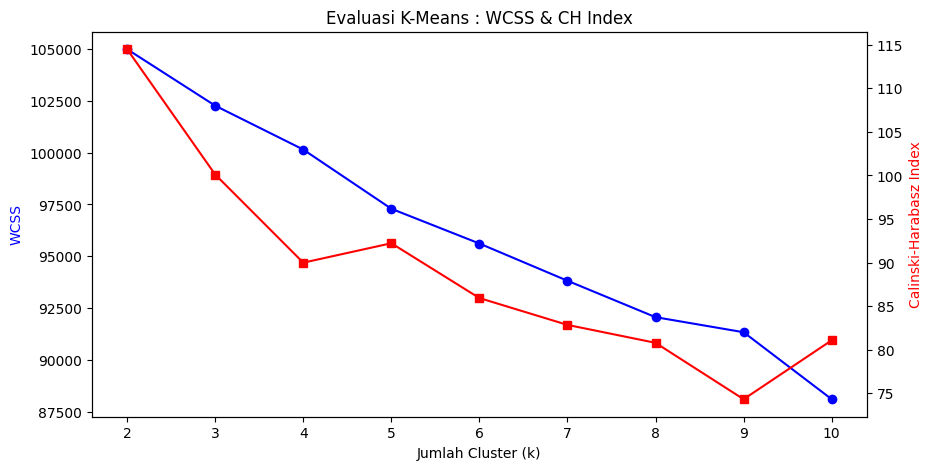

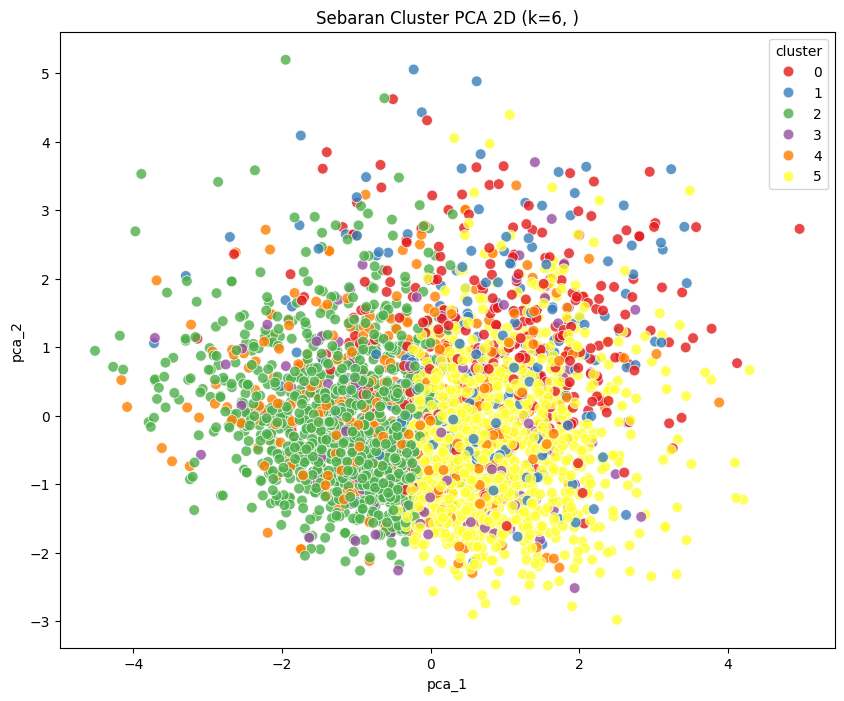

In [3]:
# 3. Filter Kolom dengan beberapa pengecualian
feature_cols = [col for col in df_norm.columns if col not in ['filename', 'artist', 'song_name', 'tempo'] and 'n_beats' not in col.lower()]
X = df_norm[feature_cols].astype(float)
print(f"Fitur yang digunakan ({len(feature_cols)} kolom): {feature_cols}")

# Evaluasi Nilai K (k=2 sampai k=10)
k_range = range(2, 11)
wcss, ch_scores = [], []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)
    ch_scores.append(calinski_harabasz_score(X, labels))

# Plot Evaluasi (Elbow & Calinski)
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(k_range, wcss, 'bo-', label='WCSS')
ax1.set_xlabel('Jumlah Cluster (k)')
ax1.set_ylabel('WCSS', color='b')
ax2 = ax1.twinx()
ax2.plot(k_range, ch_scores, 'rs-', label='CH Index')
ax2.set_ylabel('Calinski-Harabasz Index', color='r')
plt.title('Evaluasi K-Means : WCSS & CH Index')
plt.show()

# Opsi Input Preferensi k = 6
k_pref = 6
kmeans_pref = KMeans(n_clusters=k_pref, random_state=42, n_init=10)
df_norm['cluster'] = kmeans_pref.fit_predict(X)

# Visualisasi Sebaran Cluster dengan PCA 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_norm['pca_1'] = X_pca[:, 0]
df_norm['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(x='pca_1', y='pca_2', hue='cluster', palette='Set1', data=df_norm, s=60, alpha=0.8)
plt.title(f'Sebaran Cluster PCA 2D (k={k_pref}, )')
plt.show()

Section 4: Output Nilai Evaluasi Numerik, mengecek performa murni yang telah dipilih di Section 3:

In [33]:
# 4. Tampilkan Evaluasi K=6
idx_k = k_range.index(k_pref)
print(f"--- Hasil Evaluasi K-Means (k={k_pref}) ---")
print(f"Nilai WCSS (Inertia) : {wcss[idx_k]:.2f}")
print(f"Nilai CH Index       : {ch_scores[idx_k]:.2f}")

--- Hasil Evaluasi K-Means (k=6) ---
Nilai WCSS (Inertia) : 95616.62
Nilai CH Index       : 85.92


Section 5: Top 10 Rekomendasi Lagu (Euclidean vs Cosine)
Rekomendasi kini dieksekusi berdasarkan energi bas, nada, kecepatan tempo, ritme murni memperhatikan karakteristik/timbre warna suara vokal lagu itu sendiri

In [46]:
# 5. Output Rekomendasi Top 10 Lagu
# Pilih index lagu target
target_idx = 511
target_song = df_norm.loc[target_idx, 'filename']
target_cluster = df_norm.loc[target_idx, 'cluster']

cluster_songs = df_norm[df_norm['cluster'] == target_cluster].copy()
cluster_features = cluster_songs[feature_cols].values.astype(float)
target_vector = df_norm.loc[target_idx, feature_cols].values.astype(float).reshape(1, -1)

# Hitung Metrik Euclidean Distance (Kedekatan garis geometri)
dist_eucl = cdist(target_vector, cluster_features, metric='euclidean').flatten()
cluster_songs['dist_euclidean'] = dist_eucl

# Hitung Metrik Cosine Similarity (Kecocokan Profil/Arah Sudut)
dist_cos = cdist(target_vector, cluster_features, metric='cosine').flatten()
cluster_songs['sim_cosine'] = 1 - dist_cos

# Urutkan dan pisahkan rekomendasi tanpa memasukkan lagu target itu sendiri
rec_eucl = cluster_songs[cluster_songs['filename'] != target_song].sort_values('dist_euclidean').head(3)
rec_cos = cluster_songs[cluster_songs['filename'] != target_song].sort_values('sim_cosine', ascending=False).head(3)

print(f"\n--- 5. Top 10 Rekomendasi untuk: '{target_song}' (Cluster {target_cluster}) ---")
print("\n>> Berdasarkan Euclidean Distance (Semakin Kecil, Semakin Dekat):")
display(rec_eucl[['artist', 'song_name', 'tempo', 'cluster', 'dist_euclidean']])

print("\n>> Berdasarkan Cosine Similarity (Semakin Mendekati 1, Semakin Mirip Profilnya):")
display(rec_cos[['artist','song_name', 'tempo', 'cluster', 'sim_cosine']])


--- 5. Top 10 Rekomendasi untuk: 'D'Bagindas-Empat Mata.mp3' (Cluster 4) ---

>> Berdasarkan Euclidean Distance (Semakin Kecil, Semakin Dekat):


,artist,song_name,tempo,cluster,dist_euclidean
695,Lissa,Keong Racun,112.347,4,3.131413
44,Kangen Band,Tiba Waktunya,69.837,4,4.261956
1648,Audiotricz,Energy,161.499,4,4.341638



>> Berdasarkan Cosine Similarity (Semakin Mendekati 1, Semakin Mirip Profilnya):


,artist,song_name,tempo,cluster,sim_cosine
695,Lissa,Keong Racun,112.347,4,0.807756
1648,Audiotricz,Energy,161.499,4,0.623315
70,Briptu Norman,Cinta Cinta,92.285,4,0.591037


In [34]:
# LANJUTAN Output Rekomendasi Top 10 Lagu LANJUTAN
# Pilih index lagu target
target_idx = 15
target_song = df_norm.loc[target_idx, 'filename']
target_cluster = df_norm.loc[target_idx, 'cluster']

cluster_songs = df_norm[df_norm['cluster'] == target_cluster].copy()
cluster_features = cluster_songs[feature_cols].values.astype(float)
target_vector = df_norm.loc[target_idx, feature_cols].values.astype(float).reshape(1, -1)

# Hitung Metrik Euclidean Distance (Kedekatan garis geometri)
dist_eucl = cdist(target_vector, cluster_features, metric='euclidean').flatten()
cluster_songs['dist_euclidean'] = dist_eucl

# Hitung Metrik Cosine Similarity (Kecocokan Profil/Arah Sudut)
dist_cos = cdist(target_vector, cluster_features, metric='cosine').flatten()
cluster_songs['sim_cosine'] = 1 - dist_cos

# =====================================================================
# PERUBAHAN: Hapus filter yang membuang target_song.
# Ubah .head(10) menjadi .head(11) jika Anda ingin 1 Lagu Target + 10 Rekomendasi
# =====================================================================
rec_eucl = cluster_songs.sort_values('dist_euclidean').head(6)
rec_cos = cluster_songs.sort_values('sim_cosine', ascending=False).head(6)

print(f"\n--- 5. Top Rekomendasi untuk: '{target_song}' (Cluster {target_cluster}) ---")
print("\n>> Berdasarkan Euclidean Distance (Semakin Kecil, Semakin Dekat):")
display(rec_eucl[['artist', 'song_name', 'tempo', 'cluster', 'dist_euclidean']])

print("\n>> Berdasarkan Cosine Similarity (Semakin Mendekati 1, Semakin Mirip Profilnya):")
display(rec_cos[['artist','song_name', 'tempo', 'cluster', 'sim_cosine']])


--- 5. Top Rekomendasi untuk: 'Linkin Park - Crawling.mp3' (Cluster 2) ---

>> Berdasarkan Euclidean Distance (Semakin Kecil, Semakin Dekat):


,artist,song_name,tempo,cluster,dist_euclidean
15,Linkin Park,Crawling,103.359,2,0.000000
962,None,Nagih Janji,123.047,2,6.582164
381,Eurythmics,Sweet Dreams (We Are Magonia Remix),123.047,2,7.291601
2554,Serzo,Feel It Tonight,151.999,2,7.297174
846,Chili,Maafkan,143.555,2,7.324794
2215,"Kayzo, Micah Martin",Wait It Out,143.555,2,7.517356



>> Berdasarkan Cosine Similarity (Semakin Mendekati 1, Semakin Mirip Profilnya):


,artist,song_name,tempo,cluster,sim_cosine
15,Linkin Park,Crawling,103.359,2,1.000000
962,None,Nagih Janji,123.047,2,0.678834
381,Eurythmics,Sweet Dreams (We Are Magonia Remix),123.047,2,0.588195
846,Chili,Maafkan,143.555,2,0.565840
2554,Serzo,Feel It Tonight,151.999,2,0.558650
2215,"Kayzo, Micah Martin",Wait It Out,143.555,2,0.553241


In [35]:
# --- PENTING: SLICING RANK 1 ---
# Kita buang baris indeks ke-0 (Lagu Target) agar tidak merusak metrik evaluasi
eval_rec_eucl = rec_eucl.iloc[1:] 
eval_rec_cos = rec_cos.iloc[1:]

# ... (Setup variabel evaluasi dinamis seperti sebelumnya) ...

# 1. PRECISION & RECALL @K (Gunakan data yang sudah di-slice)
hits_eucl = sum(eval_rec_eucl[eval_col] == target_val)
hits_cos = sum(eval_rec_cos[eval_col] == target_val)

# ... (Perhitungan presisi dan recall tetap sama) ...

# 3. ILS & HEATMAP (Gunakan data yang sudah di-slice)
ils_eucl, matrix_eucl = calculate_ils_and_matrix(eval_rec_eucl, feature_cols)
ils_cos, matrix_cos = calculate_ils_and_matrix(eval_rec_cos, feature_cols)

# =====================================================================
# 1. PRECISION & RECALL @K
# =====================================================================
# Menghitung "Hit" (Berapa banyak yang sama dengan target_val)
hits_eucl = sum(rec_eucl[eval_col] == target_val)
hits_cos = sum(rec_cos[eval_col] == target_val)

# Hitung Metrik
prec_eucl = hits_eucl / K
prec_cos = hits_cos / K

rec_eucl_score = hits_eucl / total_relevant_in_db
rec_cos_score = hits_cos / total_relevant_in_db

print(f"Mode Evaluasi Berdasarkan : Kolom '{eval_col}'")
print(f"Nilai Target Dicari       : {target_val}")
print(f"Total Kemunculan di DB    : {total_relevant_in_db} (Di luar lagu target)")
print("-" * 40)
print(f"-> Euclidean | Precision@{K}: {prec_eucl:.2f} | Recall@{K}: {rec_eucl_score:.2f}")
print(f"-> Cosine    | Precision@{K}: {prec_cos:.2f} | Recall@{K}: {rec_cos_score:.2f}\n")

# Visualisasi Precision & Recall
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Euclidean', 'Cosine']
x = np.arange(len(labels))
width = 0.35

ax[0].bar(x - width/2, [prec_eucl, prec_cos], width, label='Precision@K', color='skyblue')
ax[0].bar(x + width/2, [rec_eucl_score, rec_cos_score], width, label='Recall@K', color='salmon')
ax[0].set_ylabel('Skor')
ax[0].set_title(f'Perbandingan Precision & Recall (Target: {eval_col})')
ax[0].set_xticks(x)
ax[0].set_xticklabels(labels)
ax[0].set_ylim(0, 1.1)
ax[0].legend()
plt.show()

NameError: name 'calculate_ils_and_matrix' is not defined

--- 6. EVALUASI LANJUTAN METRIK REKOMENDASI ---


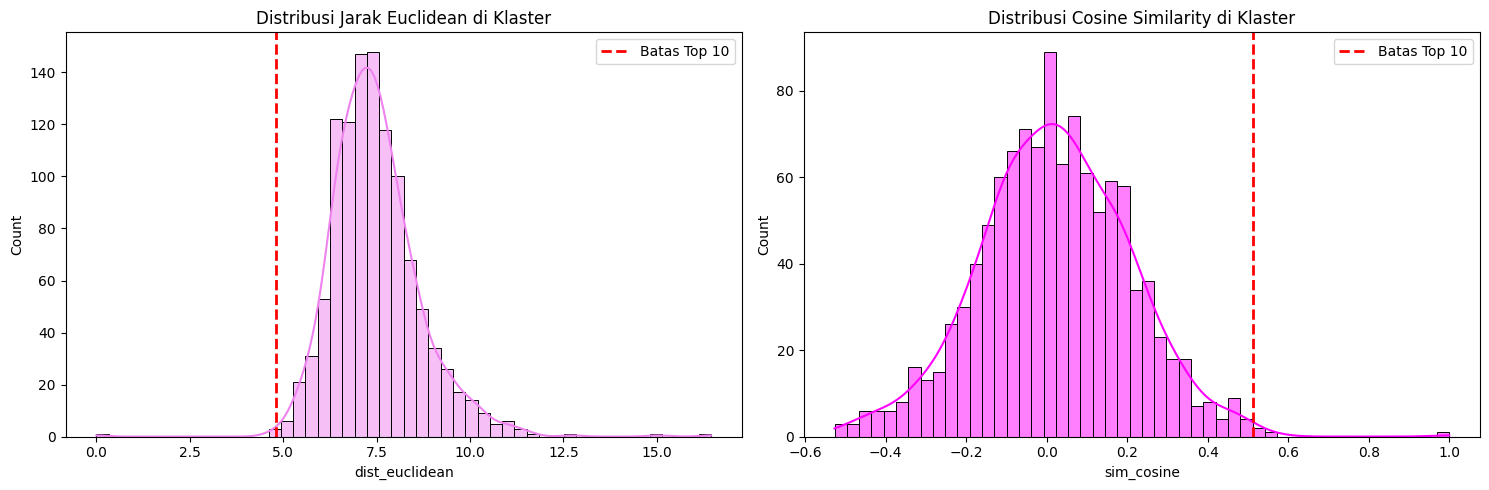


[Analisis Keberagaman / Diversity]
Intra-List Similarity (ILS) dari Top 10 Euclidean : 0.6354
Intra-List Similarity (ILS) dari Top 10 Cosine    : 0.2524

Kesimpulan Sementara:
Metrik COSINE menghasilkan rekomendasi yang lebih bervariasi secara audio (skor ILS lebih rendah).
Metrik EUCLIDEAN cenderung menghasilkan lagu yang sangat seragam satu sama lain (skor ILS lebih tinggi).


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Lanjutan dari Section 5 sebelumnya...
# cluster_songs sudah berisi kolom 'dist_euclidean' dan 'sim_cosine'
# rec_eucl adalah dataframe Top 10 Euclidean
# rec_cos adalah dataframe Top 10 Cosine

print("--- 6. EVALUASI LANJUTAN METRIK REKOMENDASI ---")

# ==========================================
# A. Visualisasi Distribusi Skor (Histogram)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Distribusi Euclidean
sns.histplot(cluster_songs['dist_euclidean'], bins=50, kde=True, ax=axes[0], color='violet')
axes[0].axvline(rec_eucl['dist_euclidean'].max(), color='red', linestyle='dashed', linewidth=2, 
                label='Batas Top 10')
axes[0].set_title('Distribusi Jarak Euclidean di Klaster')
axes[0].legend()

# Plot Distribusi Cosine Similarity
sns.histplot(cluster_songs['sim_cosine'], bins=50, kde=True, ax=axes[1], color='magenta')
axes[1].axvline(rec_cos['sim_cosine'].min(), color='red', linestyle='dashed', linewidth=2, 
                label='Batas Top 10')
axes[1].set_title('Distribusi Cosine Similarity di Klaster')
axes[1].legend()

plt.tight_layout()
plt.show()

# ==========================================
# B. Perhitungan Intra-List Similarity (ILS)
# ==========================================
# Mengukur seberapa mirip antar lagu di dalam daftar rekomendasi itu sendiri

def calculate_ils(recommendation_df, feature_columns):
    # Ambil nilai fitur dari lagu-lagu di top 10
    rec_features = recommendation_df[feature_columns].values
    
    # Hitung semua kombinasi pasangan dalam Top 10
    # Menggunakan Cosine Similarity untuk menilai kemiripan antar pasangan
    distances = cdist(rec_features, rec_features, metric='cosine')
    
    # Ubah menjadi similarity (1 - distance) dan ambil segitiga atas matrix (tanpa diagonal)
    similarities = 1 - distances
    ils_score = np.mean(similarities[np.triu_indices(len(similarities), k=1)])
    return ils_score

# Fitur yang digunakan dari proses sebelumnya (tanpa mfcc)
ils_eucl = calculate_ils(rec_eucl, feature_cols)
ils_cos = calculate_ils(rec_cos, feature_cols)

print(f"\n[Analisis Keberagaman / Diversity]")
print(f"Intra-List Similarity (ILS) dari Top 10 Euclidean : {ils_eucl:.4f}")
print(f"Intra-List Similarity (ILS) dari Top 10 Cosine    : {ils_cos:.4f}")

if ils_eucl < ils_cos:
    print("\nKesimpulan Sementara:")
    print("Metrik EUCLIDEAN menghasilkan rekomendasi yang lebih bervariasi secara audio (skor ILS lebih rendah).")
    print("Metrik COSINE cenderung menghasilkan lagu yang profilnya sangat mirip satu sama lain (skor ILS lebih tinggi).")
else:
    print("\nKesimpulan Sementara:")
    print("Metrik COSINE menghasilkan rekomendasi yang lebih bervariasi secara audio (skor ILS lebih rendah).")
    print("Metrik EUCLIDEAN cenderung menghasilkan lagu yang sangat seragam satu sama lain (skor ILS lebih tinggi).")

Overlap: 10.0%
--- 8.2 EVALUASI OVERLAP: JACCARD INDEX ---
Top-N (K)                 : 10 lagu per model
Jumlah Irisan (Sama)      : 1 lagu
Jumlah Gabungan (Unik)    : 4 lagu
----------------------------------------
-> Overlap Coefficient    : 0.1000 (10.0%)
-> Jaccard Index          : 0.2500 (25.0%)



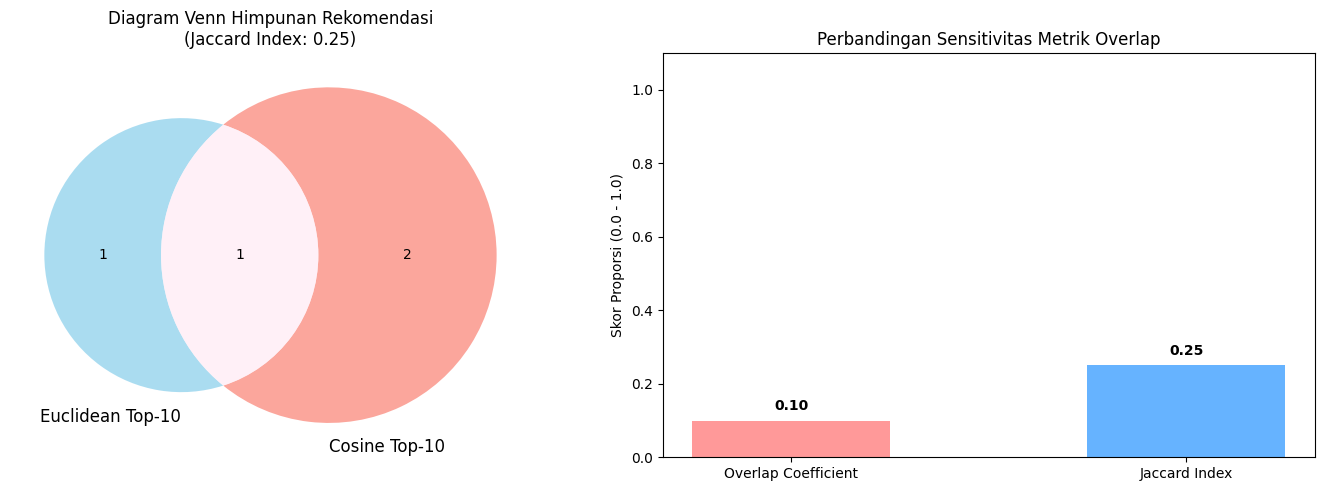

In [40]:
# --- 4. OVERLAP ---
set_eucl = set(rec_eucl['artist'])
set_cos = set(rec_cos['artist'])
overlap_songs = set_eucl.intersection(set_cos)
overlap_pct = (len(overlap_songs) / 10) * 100

print(f"Overlap: {overlap_pct}%")

# --- INDEX JACCARD ---
import matplotlib.pyplot as plt
from matplotlib_venn import venn2 # Pastikan library ini terinstal (pip install matplotlib-venn)

print("="*50)
print("--- 8.2 EVALUASI OVERLAP: JACCARD INDEX ---")
print("="*50)

# 1. Mendefinisikan Himpunan (Set) berdasarkan nama file lagu yang unik
set_eucl = set(rec_eucl['filename'])
set_cos = set(rec_cos['filename'])

# 2. Menghitung Irisan (Intersection) dan Gabungan (Union)
intersection_items = set_eucl.intersection(set_cos)
union_items = set_eucl.union(set_cos)

# 3. Menghitung Skor Overlap Coefficient & Jaccard Index
# Overlap Coeff = Irisan / min(len(A), len(B))
# Karena K selalu sama (10), min(len(A), len(B)) pasti K.
overlap_coeff = len(intersection_items) / K 

# Jaccard Index = Irisan / Union
jaccard_index = len(intersection_items) / len(union_items)

# 4. Menampilkan Hasil Numerik
print(f"Top-N (K)                 : {K} lagu per model")
print(f"Jumlah Irisan (Sama)      : {len(intersection_items)} lagu")
print(f"Jumlah Gabungan (Unik)    : {len(union_items)} lagu")
print("-" * 40)
print(f"-> Overlap Coefficient    : {overlap_coeff:.4f} ({overlap_coeff*100:.1f}%)")
print(f"-> Jaccard Index          : {jaccard_index:.4f} ({jaccard_index*100:.1f}%)\n")

# =====================================================================
# 5. VISUALISASI JACCARD INDEX (DIAGRAM VENN & BAR CHART)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Visualisasi 1: Diagram Venn (Sangat representatif untuk Jaccard)
# 
venn2([set_eucl, set_cos], 
      set_labels=('Euclidean Top-10', 'Cosine Top-10'), 
      set_colors=('skyblue', 'salmon'), 
      alpha=0.7, 
      ax=ax1)
ax1.set_title(f'Diagram Venn Himpunan Rekomendasi\n(Jaccard Index: {jaccard_index:.2f})')

# Visualisasi 2: Bar Chart Komparasi Metrik Overlap
metrics = ['Overlap Coefficient', 'Jaccard Index']
scores = [overlap_coeff, jaccard_index]
colors = ['#ff9999', '#66b3ff']

bars = ax2.bar(metrics, scores, color=colors, width=0.5)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('Skor Proporsi (0.0 - 1.0)')
ax2.set_title('Perbandingan Sensitivitas Metrik Overlap')

# Menambahkan label nilai di atas bar
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

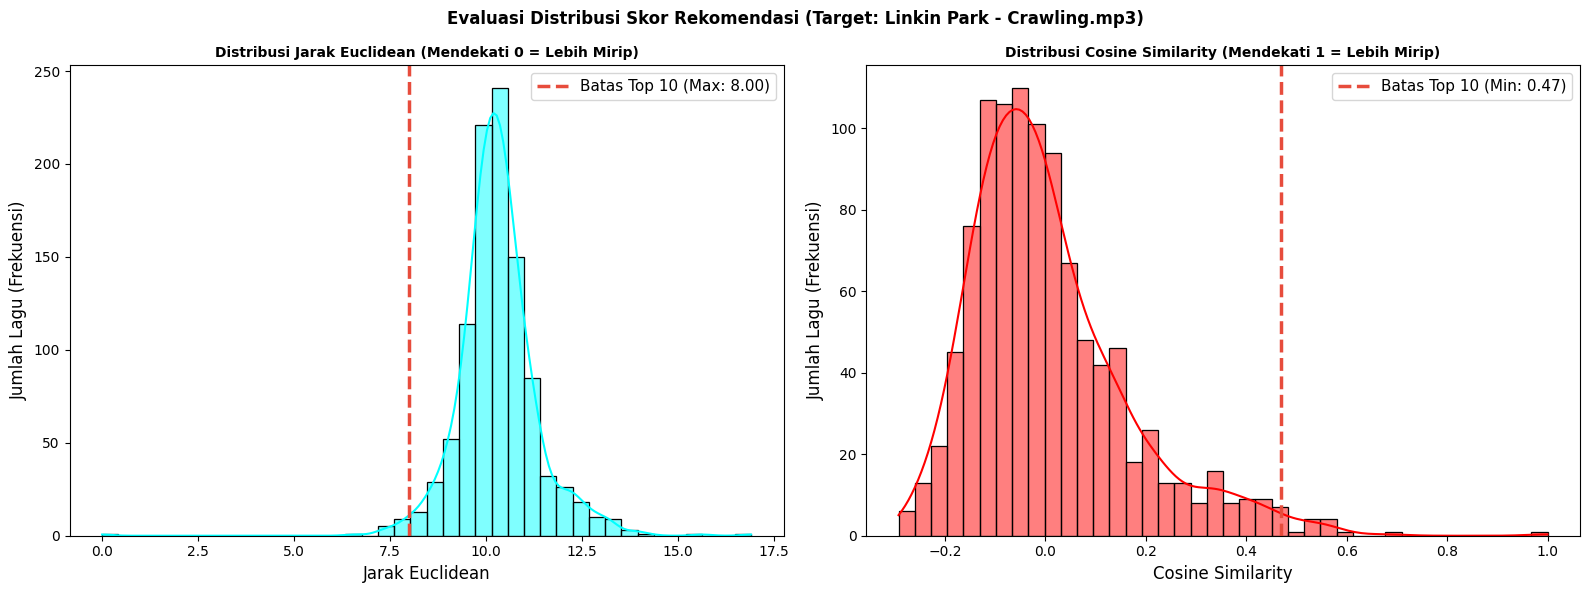

In [31]:
# --- 5. HISTOGRAM ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(cluster_songs['dist_euclidean'], bins=40, kde=True, ax=axes[0], color='cyan', edgecolor='black')
batas_eucl = rec_eucl['dist_euclidean'].max()
axes[0].axvline(batas_eucl, color='#e74c3c', linestyle='dashed', linewidth=2.5, label=f'Batas Top 10 (Max: {batas_eucl:.2f})')
axes[0].set_title('Distribusi Jarak Euclidean (Mendekati 0 = Lebih Mirip)', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Jarak Euclidean', fontsize=12)
axes[0].set_ylabel('Jumlah Lagu (Frekuensi)', fontsize=12)
axes[0].legend(fontsize=11)

sns.histplot(cluster_songs['sim_cosine'], bins=40, kde=True, ax=axes[1], color='red', edgecolor='black')
batas_cos = rec_cos['sim_cosine'].min()
axes[1].axvline(batas_cos, color='#e74c3c', linestyle='dashed', linewidth=2.5, label=f'Batas Top 10 (Min: {batas_cos:.2f})')
axes[1].set_title('Distribusi Cosine Similarity (Mendekati 1 = Lebih Mirip)', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Cosine Similarity', fontsize=12)
axes[1].set_ylabel('Jumlah Lagu (Frekuensi)', fontsize=12)
axes[1].legend(fontsize=11)

plt.suptitle(f'Evaluasi Distribusi Skor Rekomendasi (Target: {target_song})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('histogram_evaluasi_rekomendasi_final.png', dpi=300)
plt.show()

In [32]:
# --- 6. ILS (Intra-List Similarity) ---
def calculate_ils(recommendation_df, feature_columns):
    rec_features = recommendation_df[feature_columns].values.astype(float)
    distances = cdist(rec_features, rec_features, metric='cosine')
    similarities = 1 - distances
    ils_score = np.mean(similarities[np.triu_indices(len(similarities), k=1)])
    return ils_score

ils_eucl = calculate_ils(rec_eucl, feature_cols)
ils_cos = calculate_ils(rec_cos, feature_cols)

print(f"ILS Euclidean: {ils_eucl:.4f}")
print(f"ILS Cosine: {ils_cos:.4f}")

ILS Euclidean: 0.3546
ILS Cosine: 0.4188


--- 7. ANALISIS BOBOT FITUR & KEMIRIPAN PROFIL ---


C:\Users\ASUS X441UA\AppData\Local\Temp\ipykernel_864\1364700895.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Bobot', y='Fitur', data=feat_imp_df, palette='magma', ax=ax)


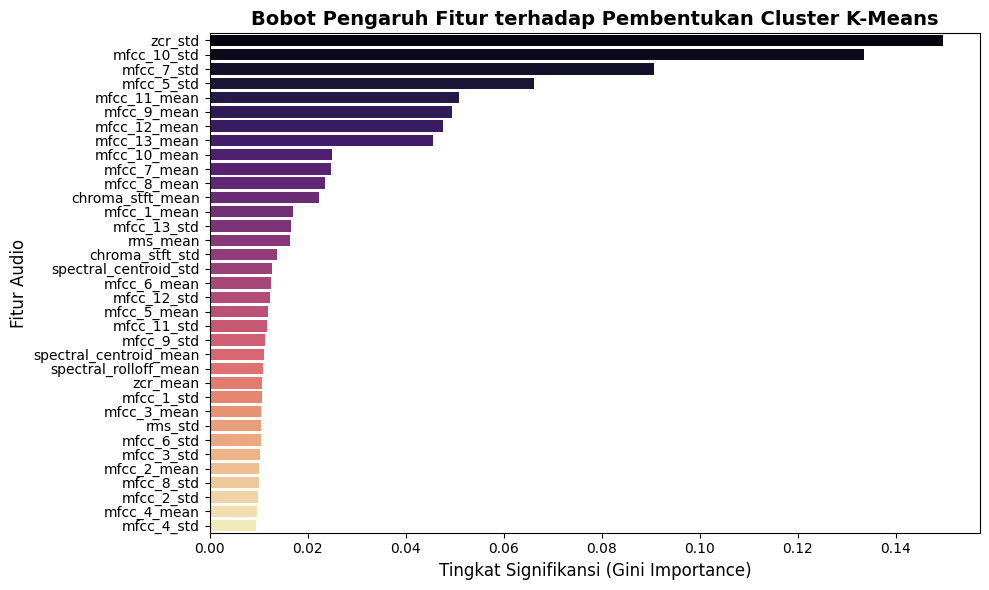

>> Tabel Bobot Fitur pada Klastering:


,Fitur,Bobot
3,zcr_std,0.149725
26,mfcc_10_std,0.133504
20,mfcc_7_std,0.090696
16,mfcc_5_std,0.066293
27,mfcc_11_mean,0.050937
23,mfcc_9_mean,0.049419
29,mfcc_12_mean,0.047695
31,mfcc_13_mean,0.045596
25,mfcc_10_mean,0.025070
19,mfcc_7_mean,0.024830


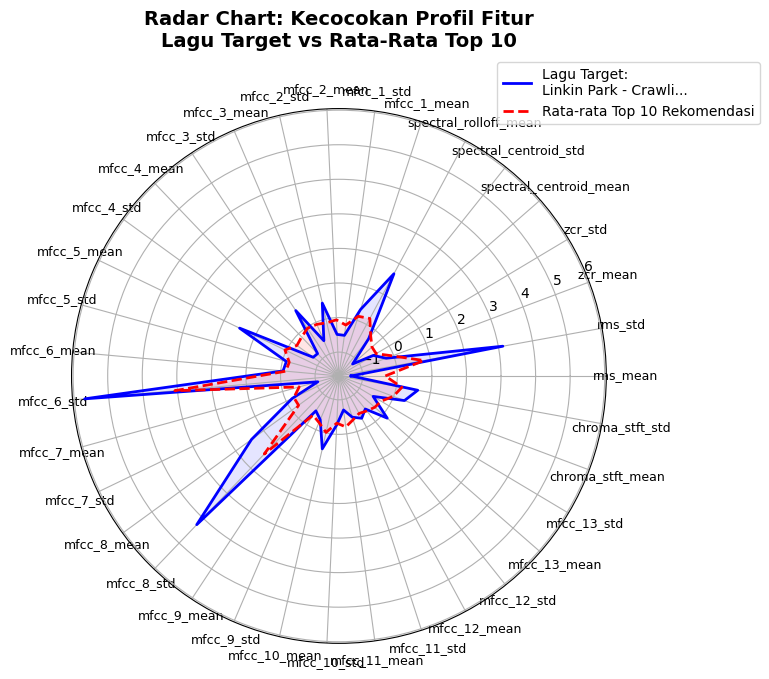

In [23]:
from sklearn.ensemble import RandomForestClassifier
from math import pi

print("--- 7. ANALISIS BOBOT FITUR & KEMIRIPAN PROFIL ---")

# =======================================================
# A. Feature Importance Menggunakan Random Forest
# Mengukur bobot seberapa kuat suatu fitur memengaruhi klaster
# =======================================================
rf = RandomForestClassifier(random_state=42, n_estimators=100)
# 'X' adalah fitur input tanpa mfcc, df_norm['cluster'] adalah label klaster target
rf.fit(X, df_norm['cluster'])

importances = rf.feature_importances_
feat_imp_df = pd.DataFrame({'Fitur': feature_cols, 'Bobot': importances})
# Urutkan berdasarkan bobot paling berpengaruh
feat_imp_df = feat_imp_df.sort_values('Bobot', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Bobot', y='Fitur', data=feat_imp_df, palette='magma', ax=ax)
ax.set_title('Bobot Pengaruh Fitur terhadap Pembentukan Cluster K-Means', fontsize=14, fontweight='bold')
ax.set_xlabel('Tingkat Signifikansi (Gini Importance)', fontsize=12)
ax.set_ylabel('Fitur Audio', fontsize=12)
plt.tight_layout()
plt.show()

print(">> Tabel Bobot Fitur pada Klastering:")
display(feat_imp_df)

# =======================================================
# B. Radar Chart: Visualisasi Profil Fitur Target vs Top 10
# Membuktikan bahwa fitur yang disarankan memang identik
# =======================================================
# Ambil nilai fitur dari lagu target
target_feat_values = df_norm.loc[target_idx, feature_cols].values
# Ambil rata-rata nilai fitur dari Top 10 Rekomendasi (Euclidean)
top10_mean_values = rec_eucl[feature_cols].mean().values

# Konfigurasi Radar Chart
categories = feature_cols
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Tutup lingkaran

target_vals = list(target_feat_values)
target_vals += target_vals[:1]
top10_vals = list(top10_mean_values)
top10_vals += top10_vals[:1]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Plot Garis Lagu Target
ax.plot(angles, target_vals, linewidth=2, linestyle='solid', label=f'Lagu Target:\n{target_song[:20]}...', color='blue')
ax.fill(angles, target_vals, 'blue', alpha=0.1)

# Plot Garis Rata-rata Top 10
ax.plot(angles, top10_vals, linewidth=2, linestyle='dashed', label='Rata-rata Top 10 Rekomendasi', color='red')
ax.fill(angles, top10_vals, 'red', alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_title('Radar Chart: Kecocokan Profil Fitur\nLagu Target vs Rata-Rata Top 10', size=14, fontweight='bold', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

--- 8. EVALUASI METRIK TOP-N REKOMENDASI ---
Mode Evaluasi Berdasarkan : Kolom 'artist'
Nilai Target Dicari       : Linkin Park
Total Kemunculan di DB    : 30 (Di luar lagu target)
----------------------------------------
-> Euclidean | Precision@10: 0.20 | Recall@10: 0.07
-> Cosine    | Precision@10: 0.20 | Recall@10: 0.07

-> Overlap Euclidean vs Cosine: 170.0% (17 lagu sama)



ValueError: Wedge sizes 'x' must be non negative values

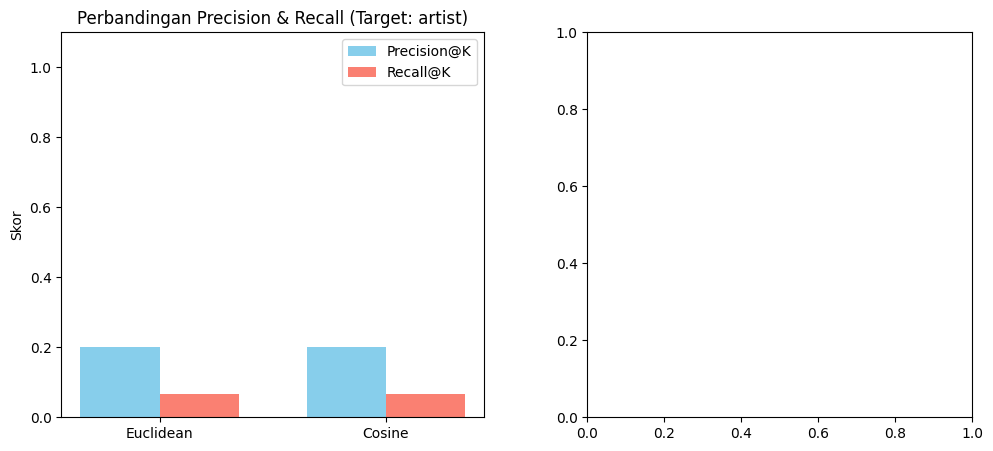

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

print("="*50)
print("--- 8. EVALUASI METRIK TOP-N REKOMENDASI ---")
print("="*50)

# =====================================================================
# --- SETUP VARIABEL DINAMIS ---
# =====================================================================
K = 10 

# ---> UBAH NILAI INI UNTUK MENGGANTI TARGET EVALUASI <---
# Opsi yang tersedia: 'artist', 'song_name', atau 'filename'
eval_col = 'artist' or 'song_name'

# Mengambil nilai target berdasarkan kolom yang dipilih
target_val = df_norm.loc[target_idx, eval_col]

# Hitung total lagu dengan kriteria yang sama di seluruh dataset 
# (Dikurangi 1 karena lagu target itu sendiri tidak ikut dihitung di output Top-N)
total_relevant_in_db = len(df_norm[df_norm[eval_col] == target_val]) - 1 

# Fallback: Mencegah error pembagian dengan 0 jika target cuma ada 1 di dataset (misal targetnya filename)
if total_relevant_in_db <= 0: 
    total_relevant_in_db = 1 

# =====================================================================
# 1. PRECISION & RECALL @K
# =====================================================================
# Menghitung "Hit" (Berapa banyak yang sama dengan target_val)
hits_eucl = sum(rec_eucl[eval_col] == target_val)
hits_cos = sum(rec_cos[eval_col] == target_val)

# Hitung Metrik
prec_eucl = hits_eucl / K
prec_cos = hits_cos / K

rec_eucl_score = hits_eucl / total_relevant_in_db
rec_cos_score = hits_cos / total_relevant_in_db

print(f"Mode Evaluasi Berdasarkan : Kolom '{eval_col}'")
print(f"Nilai Target Dicari       : {target_val}")
print(f"Total Kemunculan di DB    : {total_relevant_in_db} (Di luar lagu target)")
print("-" * 40)
print(f"-> Euclidean | Precision@{K}: {prec_eucl:.2f} | Recall@{K}: {rec_eucl_score:.2f}")
print(f"-> Cosine    | Precision@{K}: {prec_cos:.2f} | Recall@{K}: {rec_cos_score:.2f}\n")

# Visualisasi Precision & Recall
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Euclidean', 'Cosine']
x = np.arange(len(labels))
width = 0.35

ax[0].bar(x - width/2, [prec_eucl, prec_cos], width, label='Precision@K', color='skyblue')
ax[0].bar(x + width/2, [rec_eucl_score, rec_cos_score], width, label='Recall@K', color='salmon')
ax[0].set_ylabel('Skor')
ax[0].set_title(f'Perbandingan Precision & Recall (Target: {eval_col})')
ax[0].set_xticks(x)
ax[0].set_xticklabels(labels)
ax[0].set_ylim(0, 1.1)
ax[0].legend()

# =====================================================================
# 2. OVERLAP & ILS (TETAP SAMA SEPERTI SEBELUMNYA)
# =====================================================================
set_eucl = set(rec_eucl['filename'])
set_cos = set(rec_cos['filename'])

overlap_items = set_eucl.intersection(set_cos)
overlap_score = len(overlap_items) / K

print(f"-> Overlap Euclidean vs Cosine: {overlap_score*100}% ({len(overlap_items)} lagu sama)\n")

sizes = [K - len(overlap_items), len(overlap_items), K - len(overlap_items)]
labels_donut = ['Unik Euclidean', 'Irisan (Overlap)', 'Unik Cosine']
colors = ['#ff9999','#66b3ff','#99ff99']

ax[1].pie(sizes, labels=labels_donut, colors=colors, autopct='%1.1f%%', startangle=90)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)
ax[1].set_title('Persentase Overlap Output Model')
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Visualisasi 1: Diagram Venn (Sangat representatif untuk Jaccard)
# 
venn2([set_eucl, set_cos], 
      set_labels=('Euclidean Top-10', 'Cosine Top-10'), 
      set_colors=('skyblue', 'salmon'), 
      alpha=0.7, 
      ax=ax1)
ax1.set_title(f'Diagram Venn Himpunan Rekomendasi\n(Jaccard Index: {jaccard_index:.2f})')

# Visualisasi 2: Bar Chart Komparasi Metrik Overlap
metrics = ['Overlap Coefficient', 'Jaccard Index']
scores = [overlap_coeff, jaccard_index]
colors = ['#ff9999', '#66b3ff']

bars = ax2.bar(metrics, scores, color=colors, width=0.5)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('Skor Proporsi (0.0 - 1.0)')
ax2.set_title('Perbandingan Sensitivitas Metrik Overlap')

# Menambahkan label nilai di atas bar
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold')

def calculate_ils_and_matrix(df_rec, features):
    feat_matrix = df_rec[features].values.astype(float)
    sim_matrix = cosine_similarity(feat_matrix)
    ils_score = sim_matrix[np.triu_indices(len(feat_matrix), k=1)].mean()
    return ils_score, sim_matrix

ils_eucl, matrix_eucl = calculate_ils_and_matrix(rec_eucl, feature_cols)
ils_cos, matrix_cos = calculate_ils_and_matrix(rec_cos, feature_cols)

print(f"-> Skor ILS Euclidean : {ils_eucl:.4f} (Makin tinggi makin seragam/monoton)")
print(f"-> Skor ILS Cosine    : {ils_cos:.4f}\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(matrix_eucl, annot=False, cmap='YlGnBu', ax=axes[0], vmin=0.8, vmax=1.0)
axes[0].set_title(f'Heatmap Kesamaan Internal Euclidean (ILS: {ils_eucl:.2f})')
axes[0].set_xlabel('Indeks Lagu Rekomendasi')
axes[0].set_ylabel('Indeks Lagu Rekomendasi')

sns.heatmap(matrix_cos, annot=False, cmap='YlGnBu', ax=axes[1], vmin=0.8, vmax=1.0)
axes[1].set_title(f'Heatmap Kesamaan Internal Cosine (ILS: {ils_cos:.2f})')
axes[1].set_xlabel('Indeks Lagu Rekomendasi')

plt.tight_layout()
plt.show()

In [ ]:
import pickle
import pandas as pd

print("="*50)
print("--- 9. EKSPOR MODEL & DATA UNTUK FLASK APP ---")
print("="*50)

# 1. Hitung Mean & Std dari fitur numerik asli untuk normalisasi input lagu baru
feature_means = df[feature_cols].mean()
feature_stds = df[feature_cols].std()

# 2. Kemas semua data yang dibutuhkan ke dalam sebuah dictionary
export_data = {
    'kmeans_model': kmeans,        # Model K-Means yang sudah di-fit
    'df_meta': df[['filename', 'artist', 'song_name', 'tempo', 'cluster']], # Metadata untuk display
    'df_features_norm': df_norm[feature_cols], # Matriks fitur yang sudah dinormalisasi
    'feature_cols': feature_cols,        # Daftar 35 nama kolom fitur
    'scaler_mean': feature_means,        # Rata-rata fitur asli
    'scaler_std': feature_stds           # Standar deviasi fitur asli
}

# 3. Simpan ke file .pkl
with open('music_recommender_system.pkl', 'wb') as file:
    pickle.dump(export_data, file)

print("Berhasil! File 'music_recommender_system.pkl' siap digunakan di Flask.")

--- 9. EKSPOR MODEL & DATA UNTUK FLASK APP ---


KeyError: "['cluster'] not in index"

In [ ]:
import pickle
import pandas as pd

print("="*50)
print("--- 9. EKSPOR MODEL & DATA UNTUK FLASK APP ---")
print("="*50)

# =====================================================================
# ---> PERBAIKAN UTAMA DI SINI <---
# Masukkan hasil label cluster dari model K-Means ke dalam DataFrame asli.
# (Pastikan variabel model Anda bernama 'kmeans'. Jika namanya 'kmeans_model', sesuaikan).
df['cluster'] = kmeans.labels_ 
# =====================================================================

# 1. Reset index untuk memastikan keselarasan absolut (1:1 mapping)
# Sekarang kolom 'cluster' sudah ada di df dan siap diekstrak
df_meta_clean = df[['filename', 'artist', 'song_name', 'tempo', 'cluster']].copy()
df_meta_clean.reset_index(drop=True, inplace=True)

df_features_clean = df_norm[feature_cols].copy()
df_features_clean.reset_index(drop=True, inplace=True)

# 2. Konversi mean dan std ke dalam bentuk Array Numpy agar stabil di Flask
feature_means_arr = df[feature_cols].mean().values
feature_stds_arr = df[feature_cols].std().values

# 3. Kemas semua data yang dibutuhkan ke dalam sebuah dictionary
export_data = {
    'kmeans_model': kmeans,                # Model K-Means yang sudah dilatih
    'df_meta': df_meta_clean,              # Metadata yang sudah memiliki kolom 'cluster'
    'df_features_norm': df_features_clean, # Matriks fitur yang selaras
    'feature_cols': feature_cols,          # Daftar nama kolom fitur
    'scaler_mean': feature_means_arr,      # Rata-rata fitur
    'scaler_std': feature_stds_arr         # Standar deviasi fitur
}

# 4. Simpan ke file .pkl
with open('music_recommender_system.pkl', 'wb') as file:
    pickle.dump(export_data, file)

print("Berhasil! Kolom 'cluster' berhasil ditambahkan dan file .pkl siap digunakan di Flask.")

--- 9. EKSPOR MODEL & DATA UNTUK FLASK APP ---
Berhasil! Kolom 'cluster' berhasil ditambahkan dan file .pkl siap digunakan di Flask.


In [ ]:
import pickle
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
import numpy as np

# --- 1. Finalisasi Fitur (Perbaikan Tipe Data) ---
# Secara otomatis hanya memilih kolom yang berisi angka (integer atau float)
df_numeric = df_norm.select_dtypes(include=[np.number])

# Pastikan kolom seperti 'cluster' tidak ikut terbawa jika sel ini dijalankan ulang
feature_cols = [col for col in df_numeric.columns if col not in ['filename', 'artist', 'song_name', 'tempo', 'n_beats', 'pca_1', 'pca_2']]

# Buat matriks X yang sudah murni berisi angka
X = df_norm[feature_cols].values

# --- 2. Pelatihan Model K-Means (k=5) ---
k_optimal = 6
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(X)

# --- 3. Hitung Mean & Std dari df_raw untuk Normalisasi Input Baru ---
# (Pastikan df_raw sudah didefinisikan sebelumnya di notebook Anda)
scaler_mean = df[feature_cols].mean().values
scaler_std = df[feature_cols].std().values

# --- 4. Kemas Data untuk Flask ---
export_data = {
    'kmeans_model': kmeans,
    'metadata': df,                  # Menyimpan seluruh df agar Anda fleksibel memanggil kolom apapun di Flask
    'features_matrix': X,            # Matriks numerik untuk hitung similarity
    'feature_names': feature_cols,
    'scaler_mean': scaler_mean,
    'scaler_std': scaler_std
}

with open('model_rekomen_lagu.pkl', 'wb') as f:
    pickle.dump(export_data, f)

print(f"Model berhasil diekspor! Menggunakan {len(feature_cols)} fitur numerik.")

Model berhasil diekspor! Menggunakan 36 fitur numerik.
